<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/deep_learning/multitask_face_plain_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi-Task Learning for Face Analysis (Plain PyTorch)

## Introduction

**Multi-task learning (MTL)** trains a single model to solve multiple related tasks simultaneously by sharing a common feature extractor. The intuition: if a model must predict both eye positions *and* age, the shared backbone is forced to learn representations that are useful for both — acting as an implicit regulariser.

**Tasks in this notebook:**
- **Eye localisation** (regression): predict normalised coordinates $(x_l, y_l, x_r, y_r) \in [0,1]^4$

## Transfer Learning with ResNet-50

Training a vision model from scratch requires millions of images and days of compute. **Transfer learning** bypasses this by starting from a model pre-trained on **ImageNet** (1.2M images, 1000 classes).

### ResNet-50 Architecture

ResNet-50 uses **residual (skip) connections** to solve the vanishing gradient problem in deep networks:

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{W_i\}) + \mathbf{x}$$

If the optimal mapping is close to identity, the residual $\mathcal{F}$ only needs to learn a small correction — much easier than learning the full mapping from scratch. This allows training networks with 50–200+ layers.

**Our approach:** replace the final classification head (`fc` layer) with a task-specific head, and fine-tune end-to-end.

### Why ImageNet Normalisation?

ResNet-50 was trained expecting pixel values normalised as:
$$\tilde{x} = \frac{x/255 - \mu}{\sigma}, \quad \mu = [0.485, 0.456, 0.406],\; \sigma = [0.229, 0.224, 0.225]$$
These are the per-channel mean and std of the ImageNet training set. Using different normalisation would shift the activations away from the distribution the pre-trained filters expect.

## Multi-Task Loss

With multiple task heads, the total loss is a weighted sum:

$$\mathcal{L} = \sum_k \lambda_k \mathcal{L}_k$$

Here we use only the eye regression task:
$$\mathcal{L} = \text{MSE}(\hat{\mathbf{e}}, \mathbf{e}) = \frac{1}{4}\sum_{j=1}^{4}(\hat{e}_j - e_j)^2$$

Coordinates are normalised to $[0,1]$ so the loss scale is consistent regardless of image resolution.

## Notation

| Symbol | Meaning |
|--------|---------|
| $B$ | Batch size |
| $d = 2048$ | ResNet-50 backbone output dimension |
| $\mathbf{e} \in [0,1]^4$ | Ground-truth normalised eye coordinates |
| $\hat{\mathbf{e}}$ | Predicted eye coordinates |
| $\mathcal{L}_{\text{MSE}}$ | Mean squared error loss |

## Roadmap

1. Exploratory data analysis (EDA)
2. Dataset class with normalised coordinate handling
3. Train/val/test splits and DataLoaders
4. ResNet-50 backbone + eye regression head
5. Training loop with gradient clipping, checkpointing
6. Learning curves
7. Visual inference with predicted eye boxes

In [12]:

# --- 0) Setup & Config ---
import os, math, json, random, time, copy, hashlib
from pathlib import Path
from typing import Dict, Any, Optional, Tuple, List

import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageFont

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms as T
from torchvision.models import resnet50, ResNet50_Weights

import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Paths (EDIT THESE)
DATA_CSV = 'data/data.csv'
IMAGES_DIR = 'data/images'
SAVE_DIR = 'logs/'

# Training hyperparams
BATCH_SIZE = 16
NUM_WORKERS = 4
LR = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 4
PATIENCE = 5       # early stopping patience
VAL_EVERY = 1      # validate each N epochs
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CKPT_DIR = "checkpoints_plain"
os.makedirs(CKPT_DIR, exist_ok=True)

print(f"Device: {DEVICE}")


Device: cuda


## Data Download

Download and extract the face dataset from Google Drive:

In [13]:
import gdown
import zipfile
import os

file_id = '1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF'
url = f'https://drive.google.com/uc?id={file_id}'

output = 'downloaded_file.zip'
gdown.download(url, output, quiet=False)

with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('data')

os.remove(output)
print('Download and extraction completed successfully.')

Downloading...
From (original): https://drive.google.com/uc?id=1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF
From (redirected): https://drive.google.com/uc?id=1c6Gv3LB2mi3_7_gzN1q6e6echCk3sinF&confirm=t&uuid=b878567e-0712-41c1-9866-472d3b055ad2
To: /content/downloaded_file.zip
100%|██████████| 34.8M/34.8M [00:00<00:00, 119MB/s]


Download and extraction completed successfully.


## 1) Quick EDA

In [14]:
# ---- Load CSV ----
df = pd.read_csv(DATA_CSV)
print(f"CSV rows: {len(df)}")
display(df.head())

CSV rows: 5000


,im_name,gender,left_eye_x,left_eye_y,right_eye_x,right_eye_y,age
0,0.jpg,male,70,111,107,111,37
1,1.jpg,male,71,110,106,111,31
2,2.jpg,male,71,111,106,110,37
3,3.jpg,male,68,111,108,112,51
4,4.jpg,male,71,111,106,110,36



Missing expected columns: ['filename']

Basic describe:


,left_eye_x,left_eye_y,right_eye_x,right_eye_y,age
count,5000.00000,5000.00000,5000.00000,5000.000000,5000.000000
mean,69.39320,111.18780,107.60540,111.144200,37.074200
std,1.73931,1.12338,1.70689,1.179866,8.533819
min,60.00000,104.00000,93.00000,100.000000,11.000000
25%,68.00000,111.00000,107.00000,111.000000,32.000000
50%,69.00000,111.00000,108.00000,111.000000,35.000000
75%,70.00000,112.00000,109.00000,112.000000,40.000000
max,86.00000,117.00000,114.00000,122.000000,77.000000



Gender counts:


,count
gender,
female,2884
male,2116


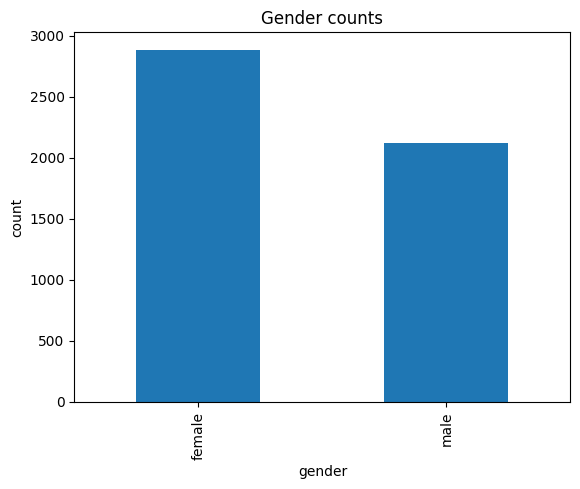

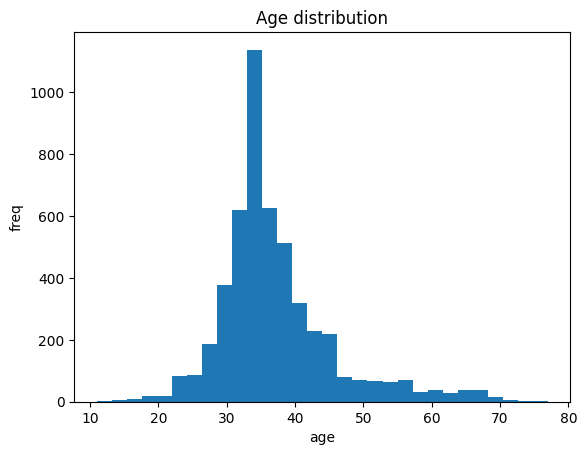

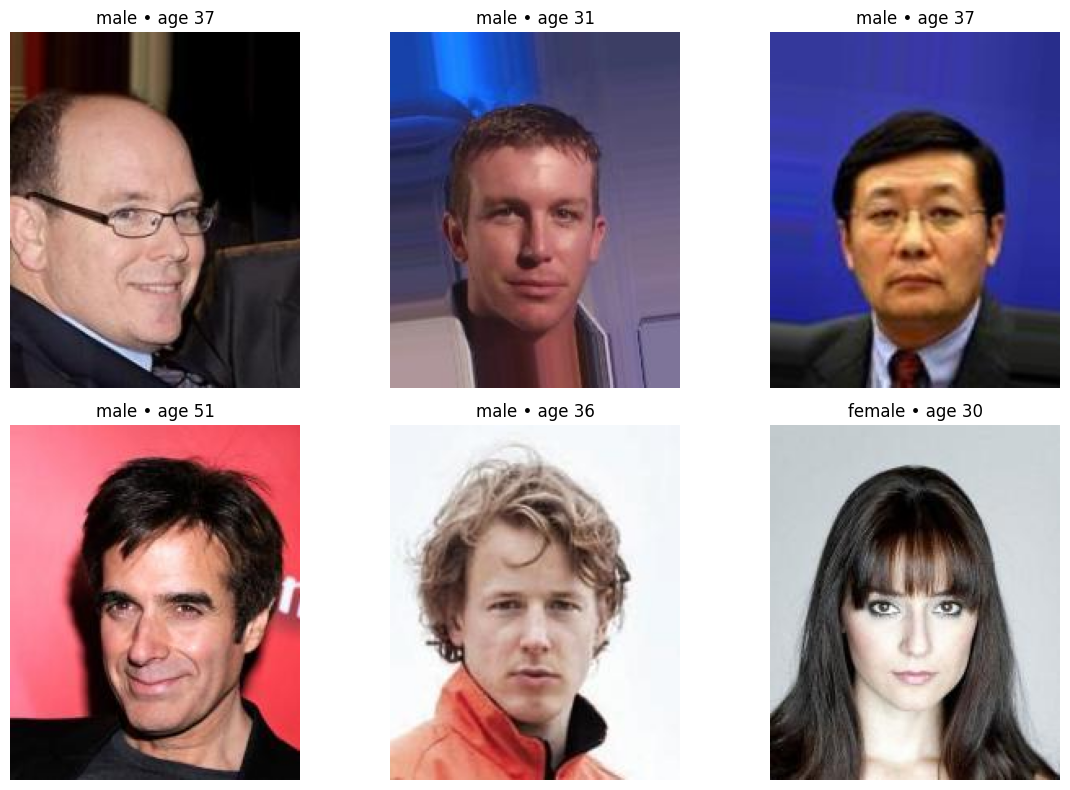

In [15]:

# Expected columns for reference:
expected_cols = ['filename', 'gender', 'left_eye_x', 'left_eye_y', 'right_eye_x', 'right_eye_y', 'age']
print("\nMissing expected columns:", [c for c in expected_cols if c not in df.columns])

# ---- Basic stats ----
print("\nBasic describe:")
display(df[['left_eye_x','left_eye_y','right_eye_x','right_eye_y','age']].describe(include='all'))

# ---- Gender balance ----
if 'gender' in df.columns:
    gb = df['gender'].value_counts(dropna=False)
    print("\nGender counts:")
    display(gb.to_frame('count'))

    # Plot with matplotlib (no seaborn)
    plt.figure()
    gb.plot(kind='bar')
    plt.title('Gender counts')
    plt.xlabel('gender')
    plt.ylabel('count')
    plt.show()

# ---- Age histogram ----
if 'age' in df.columns:
    plt.figure()
    df['age'].dropna().astype(float).plot(kind='hist', bins=30)
    plt.title('Age distribution')
    plt.xlabel('age')
    plt.ylabel('freq')
    plt.show()

# ---- Sanity check: a few images ----
def show_samples(n=6):
    n = min(n, len(df))
    cols = 3
    rows = math.ceil(n/cols)
    plt.figure(figsize=(cols*4, rows*4))
    for i in range(n):
        row = df.iloc[i]
        img_path = os.path.join(IMAGES_DIR, row['im_name'])
        try:
            img = Image.open(img_path).convert("RGB")
        except Exception as e:
            print(f"Could not open {img_path}: {e}")
            break
        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        ttl = f"{row.get('gender','?')} • age {row.get('age','?')}"
        plt.title(ttl)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(6)


## Dataset and Transforms

### Data Augmentation

We use minimal augmentation here (just resize + normalise) to keep the baseline simple. For better generalisation, you could add `ColorJitter`, `RandomHorizontalFlip`, or `RandomCrop`.

**Why normalise with ImageNet statistics?** See the theory section above — pre-trained ResNet-50 expects this input distribution.

### Coordinate Normalisation

Eye coordinates in the CSV are in *pixel space*. We normalise to $[0,1]$ by dividing by image width/height:

$$\hat{x} = x_{\text{px}} / W_{\text{image}}, \quad \hat{y} = y_{\text{px}} / H_{\text{image}}$$

This makes the regression target scale-invariant — the model generalises across different image resolutions.

## 2) Dataset & Transforms

In [16]:
# Basic transforms
train_tfms = T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])
val_tfms = T.Compose([
    T.Resize((256,256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

In [17]:

class CustomDataset(Dataset):
    """
    CSV columns:
      filename, gender('male'/'female'), left_eye_x, left_eye_y, right_eye_x, right_eye_y, age
    Eye coords in CSV are pixel coords; we normalize to [0,1] by image size.
    """
    def __init__(self, source, root_dir, transform=None):
        # Accept a path-like or a pandas DataFrame
        if isinstance(source, (str, os.PathLike)):
            self.data = pd.read_csv(source)
        elif isinstance(source, pd.DataFrame):
            self.data = source.reset_index(drop=True).copy()
        else:
            raise TypeError("source must be a CSV filepath or a pandas.DataFrame")

        expected = ["im_name","gender","left_eye_x","left_eye_y","right_eye_x","right_eye_y","age"]
        missing = [c for c in expected if c not in self.data.columns]
        if missing:
            raise ValueError(f"CSV/DataFrame is missing columns: {missing}")

        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]  # ok to use iloc here
        img_path = self.root_dir / str(row["im_name"])
        image = Image.open(img_path).convert("RGB")

        # normalize coords to [0,1] using original image size
        w, h = image.width, image.height
        left_eye_x  = float(row["left_eye_x"])  / w
        left_eye_y  = float(row["left_eye_y"])  / h
        right_eye_x = float(row["right_eye_x"]) / w
        right_eye_y = float(row["right_eye_y"]) / h

        # (optional) clip in case of slight annotation drift
        eyes = torch.tensor([left_eye_x, left_eye_y, right_eye_x, right_eye_y],
                            dtype=torch.float32).clamp_(0.0, 1.0)

        sample = {
            "image": image if self.transform is None else self.transform(image),
            "eyes": eyes,
            "path": str(img_path),
        }
        return sample


## Data Splits and DataLoaders

We use an 80/10/10 train/val/test split.

## 3) Data splits & loaders

In [18]:

# Simple split
perm = np.random.permutation(len(df))
tr_cut = int(0.8 * len(df))
va_cut = int(0.9 * len(df))
idx_trail, idx_val, idx_test = perm[:tr_cut], perm[tr_cut:va_cut], perm[va_cut:]

df_tr, df_va, df_te = df.iloc[idx_trail], df.iloc[idx_val], df.iloc[idx_test]
print(len(df_tr), len(df_va), len(df_te))

ds_tr = CustomDataset(df_tr, IMAGES_DIR, train_tfms)
ds_va = CustomDataset(df_va, IMAGES_DIR, val_tfms)
ds_te = CustomDataset(df_te, IMAGES_DIR, val_tfms)


4000 500 500


In [19]:
dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Model: ResNet-50 + Eye Regression Head

We replace the ResNet-50 classifier head with a custom regression head:

```
ResNet-50 backbone (frozen or fine-tuned)
    ↓ 2048-dim features
Linear(2048, 512) → ReLU → Dropout(0.2) → Linear(512, 4)
    ↓
4 normalised coordinates [0, 1]
```

No sigmoid on the output — we let the MSE loss handle the regression directly (the network can learn to output values in [0,1] from supervision).

## 4) Model (ResNet‑50 backbone + multi‑heads)

In [20]:

class MultiHeadNet(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        # replace fc with identity to get 2048-d features
        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 4),
            )

    def forward(self, x):
        feats = self.backbone(x)  # (B, 2048)
        out = self.head(feats)    # (B,4)
        return out


## Loss and Metric

**Loss: `MSELoss`** — minimised during training.

**Metric: `RMSELoss`** (Root Mean Squared Error) — more interpretable than MSE since it's in the same units as the coordinates.

Let's define the loss function.

In [21]:
criteria = torch.nn.MSELoss(reduction="mean")

In [22]:
# PyTorch has no built-in RMSELoss, so we define it:
# RMSE = sqrt(MSE) -> same units as the normalised coordinates.
class RMSELoss(nn.Module):
    def __init__(self, reduction="mean", eps=1e-8):
        super().__init__()
        self.mse = nn.MSELoss(reduction=reduction)
        self.eps = eps  # avoids an infinite gradient of sqrt at 0

    def forward(self, yhat, y):
        return torch.sqrt(self.mse(yhat, y) + self.eps)

metric = RMSELoss(reduction="mean")

In [23]:
model = MultiHeadNet().to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 86.5MB/s]


In [24]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

## Training Loop

### `run_epoch` function

The training loop:
1. `model.train(True)` — enables Dropout and BatchNorm training mode
2. For each batch: forward → loss → backward → **gradient clipping** → optimizer step
3. `model.train(False)` — evaluation mode for validation

**Gradient clipping** (`clip_grad_norm_`) prevents exploding gradients by rescaling the gradient vector if its norm exceeds `max_norm=1.0`. This is especially useful with fine-tuning pre-trained models.

**Learning rate scheduler** (`ReduceLROnPlateau`) halves the LR when validation loss stops improving for 2 epochs — helps escape plateaus.

## 5) Train / Validate

In [25]:
history = {
    "train_loss": [], "val_loss": [],
    "train_metric":  [], "val_metric":  [],
}

In [26]:
def run_epoch(dloader, train: bool):
    """
    Runs one epoch.
    Returns: (avg_loss, avg_metric)
    """
    model.train(train)
    total_loss, total_metric, n = 0.0, 0.0, 0

    for batch in dloader:
        x = batch["image"].to(DEVICE, non_blocking=True)
        y = batch["eyes"].to(DEVICE)        # shape: (B, 4), normalized [0,1]

        if train:
            optimizer.zero_grad()           # Restart gradients

        yhat = model(x)                      # predicted coords in [0,1] (no clamp here; the net learns it)

        loss = criteria(yhat, y)             # loss
        batch_metric  = metric(yhat, y)      # Metric

        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        batch_size = x.size(0)
        total_loss += float(loss.detach().cpu()) * batch_size
        total_metric  += float(batch_metric.detach().cpu())  * batch_size
        n += batch_size

    avg_loss = total_loss / max(n, 1)
    avg_metric  = total_metric  / max(n, 1)
    return avg_loss, avg_metric

In [27]:
best_val = float("inf")
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    # ---- Train ----
    train_loss, train_metric = run_epoch(dl_tr, train=True)

    # ---- Validate (every epoch for simplicity) ----
    with torch.no_grad():
        val_loss, val_metric = run_epoch(dl_va, train=False)
    scheduler.step(val_loss)

    # ---- Bookkeeping ----
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_metric"].append(train_metric)
    history["val_metric"].append(val_metric)

    # ---- Save best by validation loss ----
    if val_loss < best_val:
        best_val = val_loss
        torch.save({"model_state": model.state_dict()}, os.path.join(CKPT_DIR, "best.pt"))

    dt = time.time() - t0
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss {train_loss:.4f}  train_metric {train_metric:.4f} | "
          f"va_loss {val_loss:.4f}  val_metric {val_metric:.4f} | "
          f"{dt:.1f}s")

print("Best val loss:", best_val)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch 01/4 | train_loss 0.0067  train_metric 0.0680 | va_loss 0.0013  val_metric 0.0350 | 51.4s
Epoch 02/4 | train_loss 0.0020  train_metric 0.0443 | va_loss 0.0006  val_metric 0.0239 | 53.5s
Epoch 03/4 | train_loss 0.0014  train_metric 0.0370 | va_loss 0.0004  val_metric 0.0207 | 58.3s
Epoch 04/4 | train_loss 0.0013  train_metric 0.0356 | va_loss 0.0005  val_metric 0.0217 | 56.4s
Best val loss: 0.0004368176097050309


## Learning Curves

Plot train and validation loss/metric over epochs to diagnose overfitting or underfitting:

## 6) Curves

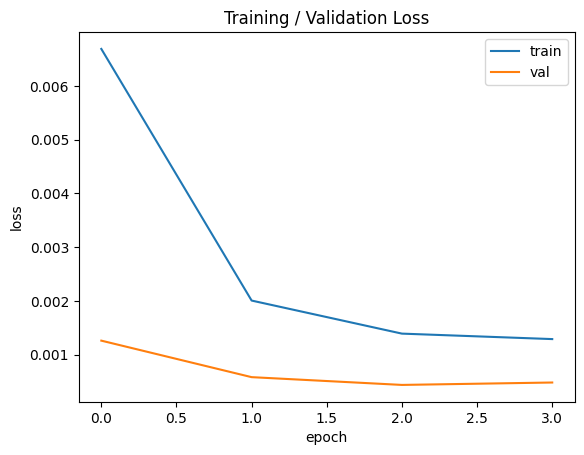

In [28]:

plt.figure()
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Training / Validation Loss");


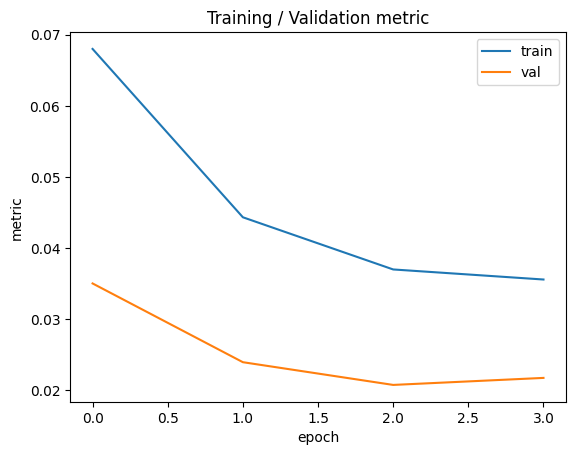

In [29]:
plt.figure()
plt.plot(history["train_metric"], label="train")
plt.plot(history["val_metric"], label="val")
plt.xlabel("epoch")
plt.ylabel("metric")
plt.legend()
plt.title("Training / Validation metric");

## Inference and Visualisation

We load the best checkpoint (saved during training) and run inference on random test images. Predicted eye positions are drawn as red bounding boxes.

## 7) Inference & Visuals

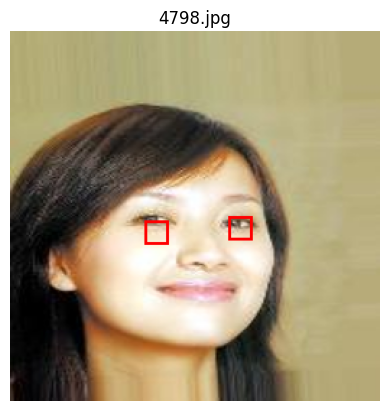

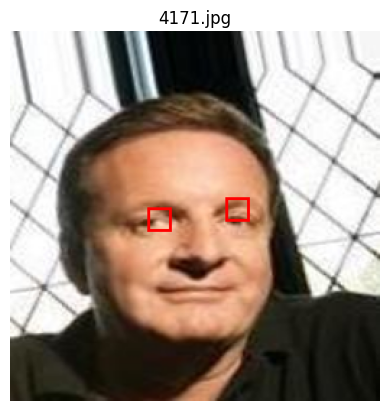

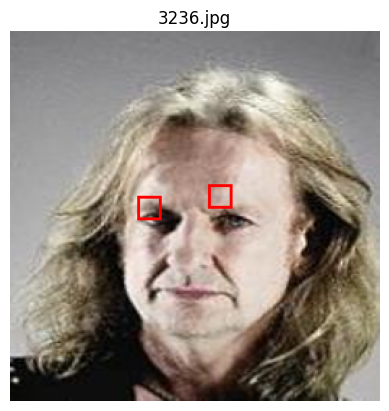

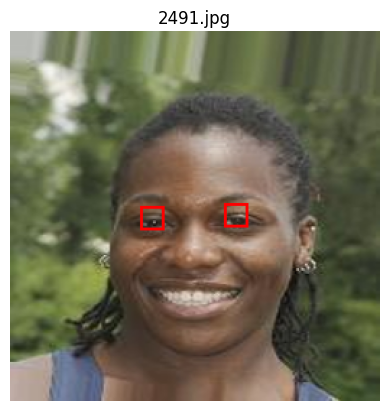

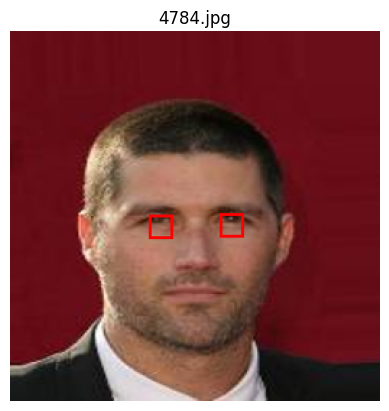

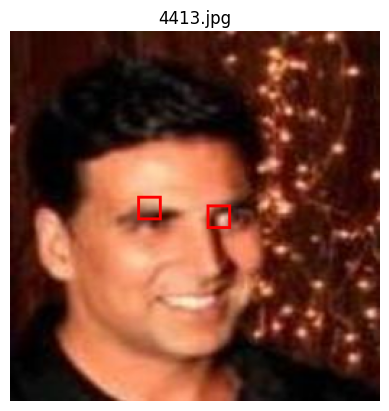

In [30]:
# ---- Load best checkpoint ----
ckpt_path = os.path.join(CKPT_DIR, "best.pt")
ckpt = torch.load(ckpt_path, map_location=DEVICE)

model = MultiHeadNet().to(DEVICE)           # no tasks arg in the simple version
model.load_state_dict(ckpt["model_state"])
model.eval()

# ---- Drawing helpers ----
from PIL import ImageDraw

def draw_eye_points_as_boxes(img: Image.Image, eyes4_norm, box_size=16):
    """
    eyes4_norm: [lx, ly, rx, ry] in normalized coords [0,1]
    Draw small rectangles centered at each eye location on the (already resized) image.
    """
    img = img.copy()
    w, h = img.size
    lx = float(eyes4_norm[0]) * w
    ly = float(eyes4_norm[1]) * h
    rx = float(eyes4_norm[2]) * w
    ry = float(eyes4_norm[3]) * h

    d = ImageDraw.Draw(img)
    for (x, y) in [(lx, ly), (rx, ry)]:
        x0 = x - box_size/2
        y0 = y - box_size/2
        x1 = x + box_size/2
        y1 = y + box_size/2
        d.rectangle([x0, y0, x1, y1], outline="red", width=2)
    return img

# (Optional) If you prefer circles instead of boxes:
def draw_eye_points_as_circles(img: Image.Image, eyes4_norm, radius=8):
    img = img.copy()
    w, h = img.size
    lx = float(eyes4_norm[0]) * w
    ly = float(eyes4_norm[1]) * h
    rx = float(eyes4_norm[2]) * w
    ry = float(eyes4_norm[3]) * h
    d = ImageDraw.Draw(img)
    for (x, y) in [(lx, ly), (rx, ry)]:
        d.ellipse([x - radius, y - radius, x + radius, y + radius], outline="red", width=2)
    return img

# ---- Show a few predictions ----
import matplotlib.pyplot as plt

N_SHOW = 6
RESIZE_FOR_SHOW = 256  # display size only (model used normalized coords, so any size is fine)

samples = []
model.eval()
with torch.no_grad():
    # choose random indices from the test set
    idxs = np.random.choice(len(ds_te), size=min(N_SHOW, len(ds_te)), replace=False)
    for i in idxs:
        item = ds_te[i]
        x = item["image"].unsqueeze(0).to(DEVICE)     # [1, 3, H, W] tensor
        pred = model(x)                                # [1, 4] normalized coords
        pred_np = pred.cpu().squeeze(0).numpy()        # shape (4,)
        samples.append({
            "path": item["path"],
            "eyes_pred_norm": pred_np,                 # keep normalized for drawing at any size
        })

for s in samples:
    p = s["path"]
    # open and resize only for visualization
    img = Image.open(p).convert("RGB").resize((RESIZE_FOR_SHOW, RESIZE_FOR_SHOW))
    img = draw_eye_points_as_boxes(img, s["eyes_pred_norm"], box_size=16)  # or draw_eye_points_as_circles
    title = os.path.basename(p)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)


## Reflection Questions

1. **Multi-task learning benefit.** Why might adding a gender classification head improve the eye localisation performance even if you don't care about gender predictions? What regularisation effect does MTL provide?

2. **Loss scale imbalance.** If you add an age regression head (range ~0–80 years) alongside the normalised eye coordinates (range 0–1), the MSE loss for age would be ~1600× larger. How would this affect training? How would you fix it?

3. **ResNet skip connections.** A plain 50-layer network without skip connections is harder to train than ResNet-50. Explain mathematically how $\mathbf{y} = \mathcal{F}(\mathbf{x}) + \mathbf{x}$ makes gradient flow easier during backpropagation.

4. **Coordinate normalisation.** Why do we normalise eye coordinates to [0,1] before training? What would happen if we trained on raw pixel coordinates from images of varying resolutions?

## Answers

**1. MTL regularisation.**
The shared backbone must produce features useful for both eye localisation and gender classification. Gender requires understanding face structure; eye localisation requires precise spatial features. Each task acts as a regulariser for the other — preventing the backbone from overfitting to either task alone. This is the **inductive transfer** benefit of MTL.

**2. Loss scale imbalance.**
The larger-scale age loss would dominate the gradient, causing the backbone to optimise mainly for age and neglect eye localisation. Fix: normalise the age target (e.g., divide by 80), or use per-task loss weighting $\lambda_{\text{age}} \ll \lambda_{\text{eyes}}$.

**3. Skip connections and gradients.**
$\frac{\partial \mathcal{L}}{\partial \mathbf{x}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \frac{\partial \mathcal{L}}{\partial \mathbf{y}} \cdot \left(\frac{\partial \mathcal{F}}{\partial \mathbf{x}} + I\right)$. The identity term $I$ ensures the gradient is always at least $\frac{\partial \mathcal{L}}{\partial \mathbf{y}}$, regardless of how small $\frac{\partial \mathcal{F}}{\partial \mathbf{x}}$ becomes. This prevents vanishing gradients in deep networks.

**4. Coordinate normalisation.**
Raw pixel coordinates depend on image resolution. An eye at pixel (100, 80) in a 200×160 image corresponds to a different relative position than in a 400×320 image. Normalised coordinates $[0,1]$ are resolution-invariant, so the model generalises across images of different sizes.